# 🧠 Model & Training
**Fashion Compatibility Project | Deep Learning Course**

### What you'll do:
- Load the data pipeline (Swin-T and ConvNeXt-T backbones)
- Implement triplet loss and contrastive loss
- Run all 4 experiments and save checkpoints to Google Drive

### The 4 experiments:
| Run | Backbone | Loss |
|-----|----------|------|
| 1 | ConvNeXt-T | Triplet |
| 2 | ConvNeXt-T | Contrastive |
| 3 | Swin-T | Triplet |
| 4 | Swin-T | Contrastive |

---
⚠️ **Before running:** `Runtime → Change runtime type → T4 GPU → Save`

## Cell 1 — Install dependencies

In [1]:
!pip install -q datasets torch torchvision Pillow numpy pandas matplotlib tqdm
print('✅ Done.')

✅ Done.


## Cell 2 — Check GPU

In [2]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('⚠️  No GPU! Go to Runtime → Change runtime type → T4 GPU')

Device: cuda
GPU: NVIDIA L4
Memory: 23.7 GB


In [3]:
import torch, gc
torch.cuda.empty_cache()
gc.collect()

96

## Cell 3 — Load dataset and build DataLoaders
This is the same pipeline as Sandra's notebook, kept here so this notebook is self-contained.

In [4]:
import random
import numpy as np
from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from collections import defaultdict

# ── Load dataset ──────────────────────────────────────────
print('Loading Marqo/polyvore...')
dataset  = load_dataset('Marqo/polyvore')
all_data = dataset['data']
total    = len(all_data)          # 94096
split_at = int(total * 0.9)
train_hf = all_data.select(range(0, split_at))
val_hf   = all_data.select(range(split_at, total))
print(f'Total: {total} | Train: {len(train_hf)} | Val: {len(val_hf)}')

# ── Transforms ────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ── Dataset class ─────────────────────────────────────────
class PolyvoreDataset(Dataset):
    """
    outfit_id extracted from item_ID: '100002074_1' -> '100002074'
    Returns (anchor, positive, negative) triplets.
    """
    def __init__(self, hf_split, transform=None):
        self.data      = hf_split
        self.transform = transform
        self.outfit_to_idx = defaultdict(list)
        for i in range(len(hf_split)):
            oid = hf_split[i]['item_ID'].rsplit('_', 1)[0]
            self.outfit_to_idx[oid].append(i)
        self.valid_outfits  = [o for o, idxs in self.outfit_to_idx.items() if len(idxs) >= 2]
        self.all_outfit_ids = list(self.outfit_to_idx.keys())

    def __len__(self): return len(self.valid_outfits)

    def _load(self, i):
        img = self.data[i]['image'].convert('RGB')
        return self.transform(img) if self.transform else img

    def __getitem__(self, idx):
        oid = self.valid_outfits[idx]
        a, p = random.sample(self.outfit_to_idx[oid], 2)
        neg_oid = random.choice([o for o in self.all_outfit_ids if o != oid])
        n = random.choice(self.outfit_to_idx[neg_oid])
        return self._load(a), self._load(p), self._load(n)

# ── Build DataLoaders with all optimizations ─────────────
BATCH_SIZE  = 64
NUM_WORKERS = 4

train_dataset = PolyvoreDataset(train_hf, train_transform)
val_dataset   = PolyvoreDataset(val_hf,   val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,   # évite de recréer les workers à chaque époque
    prefetch_factor=2           # précharge 2 batches à l'avance
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2
)

print(f'\n✅ DataLoaders ready!')
print(f'   Batch size:    {BATCH_SIZE}')
print(f'   Train batches: {len(train_loader)}')
print(f'   Val batches:   {len(val_loader)}')


Loading Marqo/polyvore...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/data-00000-of-00006.parquet:   0%|          | 0.00/428M [00:00<?, ?B/s]

data/data-00001-of-00006.parquet:   0%|          | 0.00/421M [00:00<?, ?B/s]

...

data/data-00003-of-00006.parquet:   0%|          | 0.00/416M [00:00<?, ?B/s]

data/data-00004-of-00006.parquet:   0%|          | 0.00/422M [00:00<?, ?B/s]

data/data-00005-of-00006.parquet:   0%|          | 0.00/409M [00:00<?, ?B/s]

Generating data split:   0%|          | 0/94096 [00:00<?, ? examples/s]

Total: 94096 | Train: 84686 | Val: 9410

✅ DataLoaders ready!
   Batch size:    64
   Train batches: 290
   Val batches:   34


## Cell 4 — Model: FashionEncoder (backbone + projection head)

In [5]:
import torch.nn as nn
import torchvision.models as models


class FashionEncoder(nn.Module):
    """
    Pretrained backbone (Swin-T or ConvNeXt-T) + 2-layer MLP projection head.
    Outputs L2-normalized embeddings of size `embed_dim`.
    """

    def __init__(self, backbone_name='convnext_tiny', embed_dim=128):
        super().__init__()

        if backbone_name == 'convnext_tiny':
            base        = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
            in_features = base.classifier[2].in_features   # 768
            base.classifier = nn.Identity()

        elif backbone_name == 'swin_t':
            base        = models.swin_t(weights=models.Swin_T_Weights.IMAGENET1K_V1)
            in_features = base.head.in_features             # 768
            base.head   = nn.Identity()

        else:
            raise ValueError(f'Unknown backbone: {backbone_name}. Use "convnext_tiny" or "swin_t"')

        self.backbone  = base
        self.projector = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Linear(256, embed_dim)
        )

    def forward(self, x):
        feat = self.backbone(x)
        # ConvNeXt returns [B, C, 1, 1] after global pooling — flatten
        if feat.dim() > 2:
            feat = feat.flatten(1)
        emb = self.projector(feat)
        return nn.functional.normalize(emb, p=2, dim=1)   # L2 normalize


# Quick test: both backbones
dummy = torch.randn(2, 3, 224, 224)
for name in ['convnext_tiny', 'swin_t']:
    m   = FashionEncoder(name, embed_dim=128)
    out = m(dummy)
    print(f'{name}: output {out.shape} | norms: {out.norm(dim=1).tolist()}')

print('\n✅ Both backbones work!')

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 226MB/s]


convnext_tiny: output torch.Size([2, 128]) | norms: [1.0, 0.9999999403953552]
Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:00<00:00, 234MB/s] 


swin_t: output torch.Size([2, 128]) | norms: [1.0, 1.0]

✅ Both backbones work!


## Cell 5 — Loss functions: Triplet and Contrastive

In [6]:
import torch.nn as nn
import torch.nn.functional as F

# ── Triplet Loss — PyTorch natif ✅ ───────────────────────
# torch.nn.TripletMarginLoss: max(0, d(a,p) - d(a,n) + margin)
triplet_loss_fn = nn.TripletMarginLoss(margin=0.3, p=2, reduction='mean')

# ── Contrastive Loss — custom ─────────────────────────────
def contrastive_loss(anchor, positive, negative, margin=1.0):
    d_pos = F.pairwise_distance(anchor, positive)
    d_neg = F.pairwise_distance(anchor, negative)
    return (d_pos.pow(2) + F.relu(margin - d_neg).pow(2)).mean()

# ── Wrappers uniformes ────────────────────────────────────
def triplet_loss(anchor, positive, negative):
    return triplet_loss_fn(anchor, positive, negative)

# Quick test
a = F.normalize(torch.randn(4, 128), dim=1)
p = F.normalize(torch.randn(4, 128), dim=1)
n = F.normalize(torch.randn(4, 128), dim=1)
print(f'Triplet loss     (nn.TripletMarginLoss): {triplet_loss(a, p, n).item():.4f}')
print(f'Contrastive loss (custom):               {contrastive_loss(a, p, n).item():.4f}')
print('✅ Loss functions OK')


Triplet loss     (nn.TripletMarginLoss): 0.2566
Contrastive loss (custom):               1.9736
✅ Loss functions OK


## Cell 6 — Training and validation loop functions

In [7]:
from tqdm import tqdm

# ── Mixed precision scaler — ~2x faster on T4 ✅ ──────────
scaler = torch.cuda.amp.GradScaler()

def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    total = 0.0
    for a, p, n in tqdm(loader, desc='  Train', leave=False):
        a, p, n = a.to(device, non_blocking=True), \
                  p.to(device, non_blocking=True), \
                  n.to(device, non_blocking=True)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():           # float16 forward pass
            loss = loss_fn(model(a), model(p), model(n))
        scaler.scale(loss).backward()             # scaled backward
        scaler.step(optimizer)
        scaler.update()
        total += loss.item()
    return total / len(loader)


def validate(model, loader, loss_fn, device):
    model.eval()
    total = 0.0
    with torch.no_grad():
        for a, p, n in tqdm(loader, desc='  Val  ', leave=False):
            a, p, n = a.to(device, non_blocking=True), \
                      p.to(device, non_blocking=True), \
                      n.to(device, non_blocking=True)
            with torch.cuda.amp.autocast():
                total += loss_fn(model(a), model(p), model(n)).item()
    return total / len(loader)

print('✅ Training loop with mixed precision (autocast) ready.')


✅ Training loop with mixed precision (autocast) ready.


/tmp/ipykernel_1044/828304799.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


## Cell 7 — Mount Google Drive (to save checkpoints safely)

In [9]:
import os
from google.colab import drive

drive.mount('/content/drive')
SAVE_DIR = '/content/drive/MyDrive/DL_Project_Checkpoints'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'✅ Checkpoints will be saved to: {SAVE_DIR}')

Mounted at /content/drive
✅ Checkpoints will be saved to: /content/drive/MyDrive/DL_Project_Checkpoints


## Cell 8 — ⚙️ RUN AN EXPERIMENT

**Change only the first 2 lines to switch between the 4 runs:**

| Run | BACKBONE | LOSS_FN |
|-----|----------|---------|
| 1 ✅ | `'convnext_tiny'` | `'triplet'` |
| 2   | `'convnext_tiny'` | `'contrastive'` |
| 3   | `'swin_t'` | `'triplet'` |
| 4   | `'swin_t'` | `'contrastive'` |

In [10]:
import os, gc
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'

# ══════════════════════════════════════════════════════════
#  ALL 4 EXPERIMENTS — runs automatically, no manual changes
# ══════════════════════════════════════════════════════════

EXPERIMENTS = [
    {'backbone': 'convnext_tiny', 'loss': 'triplet'},
    {'backbone': 'convnext_tiny', 'loss': 'contrastive'},
    {'backbone': 'swin_t',        'loss': 'triplet'},
    {'backbone': 'swin_t',        'loss': 'contrastive'},
]

EMBED_DIM  = 128
MAX_EPOCHS = 30
PATIENCE   = 5
LR_HEAD    = 1e-4
LR_BACK    = 1e-5

all_results = {}
all_curves  = {}

for exp in EXPERIMENTS:
    BACKBONE = exp['backbone']
    LOSS_FN  = exp['loss']
    RUN_NAME = f"{BACKBONE}__{LOSS_FN}"

    print('\n' + '═' * 55)
    print(f'  🚀 RUN: {RUN_NAME}')
    print('═' * 55)

    # Free GPU memory from previous run
    torch.cuda.empty_cache()
    gc.collect()

    # Loss function
    loss_fn = triplet_loss if LOSS_FN == 'triplet' else contrastive_loss

    # Reset scaler for each run
    scaler = torch.cuda.amp.GradScaler()

    # Build model
    model = FashionEncoder(BACKBONE, embed_dim=EMBED_DIM).to(device)

    # ── Phase 1: freeze backbone, warmup projection head ──
    for p in model.backbone.parameters():
        p.requires_grad = False

    optimizer = torch.optim.AdamW(
        model.projector.parameters(), lr=LR_HEAD, weight_decay=1e-4
    )

    print('Phase 1: warmup projection head (3 epochs)...')
    for epoch in range(1, 4):
        tl = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
        vl = validate(model, val_loader, loss_fn, device)
        print(f'  Warmup {epoch}/3  train={tl:.4f}  val={vl:.4f}')

    # ── Phase 2: unfreeze backbone, full fine-tuning ───────
    print('\nPhase 2: full fine-tuning...')
    for p in model.backbone.parameters():
        p.requires_grad = True

    optimizer = torch.optim.AdamW([
        {'params': model.backbone.parameters(),  'lr': LR_BACK},
        {'params': model.projector.parameters(), 'lr': LR_HEAD}
    ], weight_decay=1e-4)

    best_val   = float('inf')
    no_improve = 0
    train_losses, val_losses = [], []

    for epoch in range(1, MAX_EPOCHS + 1):
        tl = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
        vl = validate(model, val_loader, loss_fn, device)
        train_losses.append(tl)
        val_losses.append(vl)

        print(f'Epoch {epoch:02d}/{MAX_EPOCHS}  train={tl:.4f}  val={vl:.4f}', end='')

        if vl < best_val:
            best_val   = vl
            no_improve = 0
            ckpt = os.path.join(SAVE_DIR, f'{RUN_NAME}__best.pt')
            torch.save(model.state_dict(), ckpt)
            print('  💾 saved')
        else:
            no_improve += 1
            print(f'  (no improve {no_improve}/{PATIENCE})')
            if no_improve >= PATIENCE:
                print(f'\n⏹️  Early stopping.')
                break

    all_results[RUN_NAME] = best_val
    all_curves[RUN_NAME]  = (train_losses, val_losses)

    print(f'\n✅ Done: {RUN_NAME}  |  Best val loss: {best_val:.4f}')

    del model
    torch.cuda.empty_cache()
    gc.collect()

# Final summary
print('\n' + '═' * 55)
print('  📊 FINAL RESULTS')
print('═' * 55)
print(f'  {"Run":<35} {"Best Val Loss"}')
print('  ' + '-' * 50)
for run, val in all_results.items():
    print(f'  {run:<35} {val:.4f}')
print('═' * 55)



═══════════════════════════════════════════════════════
  🚀 RUN: convnext_tiny__triplet
═══════════════════════════════════════════════════════


/tmp/ipykernel_1044/3097259074.py:41: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Phase 1: warmup projection head (3 epochs)...


  Train:   0%|          | 0/290 [00:00<?, ?it/s]/tmp/ipykernel_1044/828304799.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():           # float16 forward pass
  Val  :   0%|          | 0/34 [00:00<?, ?it/s]/tmp/ipykernel_1044/828304799.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


  Warmup 1/3  train=0.2826  val=0.2608


...

Epoch 12/30  train=0.4403  val=0.4364  (no improve 1/5)


Epoch 13/30  train=0.4380  val=0.4391  (no improve 2/5)


Epoch 14/30  train=0.4375  val=0.4415  (no improve 3/5)


Epoch 15/30  train=0.4361  val=0.4397  (no improve 4/5)


Epoch 16/30  train=0.4354  val=0.4413  (no improve 5/5)

⏹️  Early stopping.

✅ Done: swin_t__contrastive  |  Best val loss: 0.4334

═══════════════════════════════════════════════════════
  📊 FINAL RESULTS
═══════════════════════════════════════════════════════
  Run                                 Best Val Loss
  --------------------------------------------------
  convnext_tiny__triplet              0.1930
  convnext_tiny__contrastive          0.4372
  swin_t__triplet                     0.1920
  swin_t__contrastive                 0.4334
═══════════════════════════════════════════════════════


## Cell 9 — Plot training curves

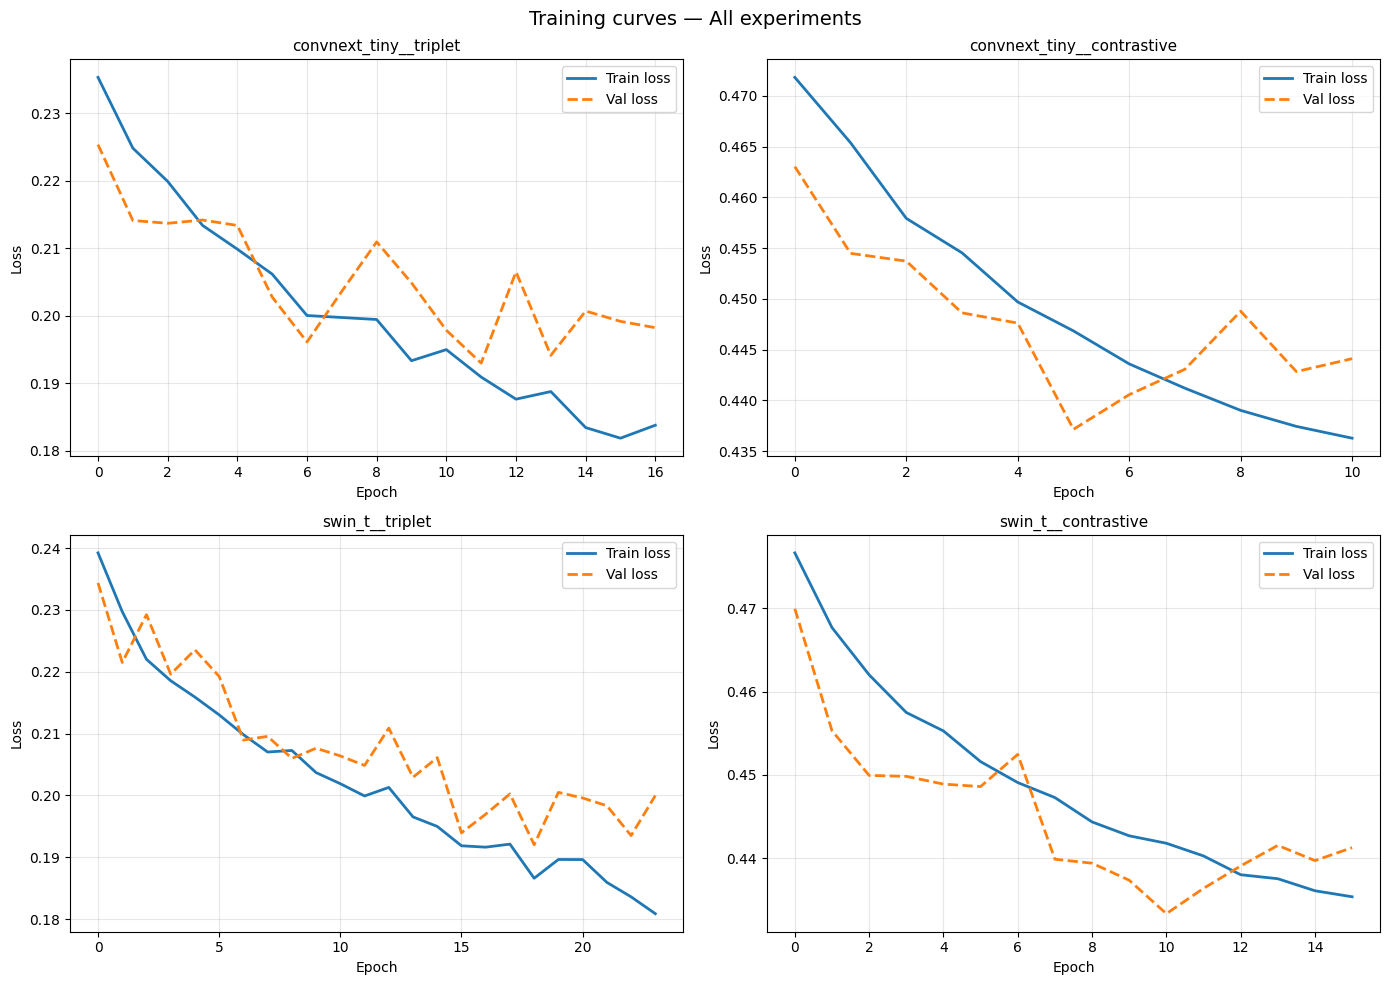

✅ All curves saved to /content/drive/MyDrive/DL_Project_Checkpoints/all_experiments__curves.png


In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Training curves — All experiments', fontsize=14)

for ax, (run_name, (train_losses, val_losses)) in zip(axes.flat, all_curves.items()):
    ax.plot(train_losses, label='Train loss', linewidth=2)
    ax.plot(val_losses,   label='Val loss',   linewidth=2, linestyle='--')
    ax.set_title(run_name, fontsize=11)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
curve_path = os.path.join(SAVE_DIR, 'all_experiments__curves.png')
plt.savefig(curve_path, dpi=120)
plt.show()
print(f'✅ All curves saved to {curve_path}')


## Cell 10 — Results tracker (fill after each run)

In [12]:
print('\n' + '═' * 55)
print('  📋 RESULTS SUMMARY')
print('═' * 55)
print(f'  {"Run":<35} {"Best Val Loss"}')
print('  ' + '-' * 50)
for run, val in all_results.items():
    status = f'{val:.4f}' if val is not None else 'pending...'
    print(f'  {run:<35} {status}')
print('═' * 55)
print()
print('  Baselines from literature (on Polyvore):')
print('  Type-Aware (Vasileva 2018):   AUC ~0.88 | FITB ~57%')
print('  Unsup. Cond. (Tan 2019):      AUC ~0.91 | FITB ~67%')
print('═' * 55)



═══════════════════════════════════════════════════════
  📋 RESULTS SUMMARY
═══════════════════════════════════════════════════════
  Run                                 Best Val Loss
  --------------------------------------------------
  convnext_tiny__triplet              0.1930
  convnext_tiny__contrastive          0.4372
  swin_t__triplet                     0.1920
  swin_t__contrastive                 0.4334
═══════════════════════════════════════════════════════

  Baselines from literature (on Polyvore):
  Type-Aware (Vasileva 2018):   AUC ~0.88 | FITB ~57%
  Unsup. Cond. (Tan 2019):      AUC ~0.91 | FITB ~67%
═══════════════════════════════════════════════════════


## Cell 11 — 🔍 Inference & Retrieval Pipeline
Embedding extraction, KNN retrieval, and evaluation metrics (AUC, FITB, Recall@10) for all 4 runs.

In [13]:
from sklearn.metrics import roc_auc_score
from collections import defaultdict
import torch.nn.functional as F

# Inference dataset — no triplets, just image + metadata
class PolyvoreInferenceDataset(Dataset):
    def __init__(self, hf_split, transform=None):
        self.data       = hf_split
        self.transform  = transform
        self.item_ids   = [hf_split[i]['item_ID'] for i in range(len(hf_split))]
        self.outfit_ids = [iid.rsplit('_', 1)[0] for iid in self.item_ids]
        self.categories = [hf_split[i]['category'] for i in range(len(hf_split))]
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        img = self.data[idx]['image'].convert('RGB')
        if self.transform: img = self.transform(img)
        return img, idx

inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_inf    = PolyvoreInferenceDataset(val_hf, inference_transform)
inf_loader = DataLoader(val_inf, batch_size=64, shuffle=False,
                        num_workers=4, pin_memory=True)

def extract_embeddings(run_name):
    """Load checkpoint and extract embeddings for all val items."""
    backbone   = run_name.split('__')[0]
    ckpt_path  = os.path.join(SAVE_DIR, f'{run_name}__best.pt')
    m = FashionEncoder(backbone, embed_dim=128).to(device)
    m.load_state_dict(torch.load(ckpt_path, map_location=device))
    m.eval()

    all_embs, all_idxs = [], []
    with torch.no_grad():
        for imgs, idxs in tqdm(inf_loader, desc=f'  Embeddings [{run_name}]', leave=False):
            with torch.amp.autocast('cuda'):
                embs = m(imgs.to(device))
            all_embs.append(embs.cpu())
            all_idxs.extend(idxs.tolist())

    emb_db      = torch.cat(all_embs, dim=0)   # [N, 128]
    outfit_ids  = [val_inf.outfit_ids[i] for i in all_idxs]
    categories  = [val_inf.categories[i] for i in all_idxs]
    del m; torch.cuda.empty_cache()
    return emb_db, outfit_ids, categories

print('✅ Inference setup ready.')

✅ Inference setup ready.


In [14]:
def compute_auc(embedding_db, db_outfit_ids, n_pairs=2000):
    """
    AUC: score cosine similarity between compatible pairs (label=1)
    vs random incompatible pairs (label=0).
    """
    outfit_to_idx = defaultdict(list)
    for i, oid in enumerate(db_outfit_ids):
        outfit_to_idx[oid].append(i)
    valid = [o for o, idxs in outfit_to_idx.items() if len(idxs) >= 2]

    scores, labels = [], []
    for _ in range(n_pairs):
        # Compatible pair (label=1)
        oid  = random.choice(valid)
        i, j = random.sample(outfit_to_idx[oid], 2)
        scores.append(torch.dot(embedding_db[i], embedding_db[j]).item())
        labels.append(1)
        # Incompatible pair (label=0)
        o1, o2 = random.sample(valid, 2)
        i = random.choice(outfit_to_idx[o1])
        j = random.choice(outfit_to_idx[o2])
        scores.append(torch.dot(embedding_db[i], embedding_db[j]).item())
        labels.append(0)
    return roc_auc_score(labels, scores)


def compute_fitb(embedding_db, db_outfit_ids, n_questions=500, n_candidates=4):
    """
    FITB: given an incomplete outfit (N-1 items),
    select the correct missing item from n_candidates.
    """
    outfit_to_idx = defaultdict(list)
    for i, oid in enumerate(db_outfit_ids):
        outfit_to_idx[oid].append(i)
    valid   = [o for o, idxs in outfit_to_idx.items() if len(idxs) >= 3]
    all_idx = list(range(len(db_outfit_ids)))
    correct = 0

    for _ in range(n_questions):
        oid     = random.choice(valid)
        idxs    = outfit_to_idx[oid]
        context = idxs[:-1]
        answer  = idxs[-1]
        # Average embedding of known context items
        ctx_emb = F.normalize(embedding_db[context].mean(dim=0), p=2, dim=0)
        # n-1 random distractors from different outfits
        distractors = random.sample(
            [i for i in all_idx if db_outfit_ids[i] != oid], n_candidates - 1
        )
        candidates = [answer] + distractors
        random.shuffle(candidates)
        # Pick candidate with highest compatibility score
        best = candidates[torch.matmul(embedding_db[candidates], ctx_emb).argmax().item()]
        if best == answer:
            correct += 1
    return correct / n_questions


def compute_recall_at_k(embedding_db, db_outfit_ids, k=10, n_queries=500):
    """
    Recall@K: for each query item, what fraction of truly compatible items
    (from the same outfit) appear in the top-K retrieved results?
    """
    outfit_to_idx = defaultdict(list)
    for i, oid in enumerate(db_outfit_ids):
        outfit_to_idx[oid].append(i)
    valid = [(oid, idxs) for oid, idxs in outfit_to_idx.items() if len(idxs) >= 2]
    random.shuffle(valid)
    valid = valid[:n_queries]

    recalls = []
    for oid, idxs in valid:
        q_idx    = idxs[0]
        true_pos = set(idxs[1:])           # other items from the same outfit
        sims     = torch.matmul(embedding_db, embedding_db[q_idx])
        sims[q_idx] = -1.0                 # exclude the query itself
        top_k    = torch.topk(sims, k).indices.tolist()
        recalls.append(len(set(top_k) & true_pos) / len(true_pos))
    return np.mean(recalls)

print('✅ Metric functions ready.')

✅ Metric functions ready.


In [15]:
# Evaluate all 4 runs automatically — no manual changes needed
EVAL_RUNS = [
    'convnext_tiny__triplet',
    'convnext_tiny__contrastive',
    'swin_t__triplet',
    'swin_t__contrastive',
]

all_metrics = {}

for run_name in EVAL_RUNS:
    print(f'\n{"═"*55}')
    print(f'  🔍 Evaluating: {run_name}')
    print(f'{"═"*55}')

    # Extract embeddings for this checkpoint
    emb_db, db_outfit_ids, db_categories = extract_embeddings(run_name)

    # Compute metrics
    auc      = compute_auc(emb_db, db_outfit_ids)
    fitb     = compute_fitb(emb_db, db_outfit_ids)
    recall10 = compute_recall_at_k(emb_db, db_outfit_ids)

    all_metrics[run_name] = {
        'auc': auc, 'fitb': fitb, 'recall10': recall10
    }

    print(f'  AUC:        {auc:.4f}')
    print(f'  FITB:       {fitb:.4f} ({fitb*100:.2f}%)')
    print(f'  Recall@10:  {recall10:.4f} ({recall10*100:.2f}%)')

# Final summary table
print(f'\n{"═"*65}')
print(f'  {"Run":<35} {"AUC":>6}  {"FITB":>6}  {"R@10":>6}')
print(f'  {"-"*60}')
for run, m in all_metrics.items():
    print(f'  {run:<35} {m["auc"]:>6.4f}  {m["fitb"]:>6.4f}  {m["recall10"]:>6.4f}')
print(f'{"═"*65}')
print(f'\n  Literature baselines (on Polyvore):')
print(f'  Type-Aware  (Vasileva 2018):  AUC ~0.88 | FITB ~57%')
print(f'  Unsup. Cond (Tan 2019):       AUC ~0.91 | FITB ~67%')
print(f'{"═"*65}')


═══════════════════════════════════════════════════════
  🔍 Evaluating: convnext_tiny__triplet
═══════════════════════════════════════════════════════


  AUC:        0.6971
  FITB:       0.5380 (53.80%)
  Recall@10:  0.0052 (0.52%)

═══════════════════════════════════════════════════════
  🔍 Evaluating: convnext_tiny__contrastive
═══════════════════════════════════════════════════════


  AUC:        0.6995
  FITB:       0.4880 (48.80%)
  Recall@10:  0.0099 (0.99%)

═══════════════════════════════════════════════════════
  🔍 Evaluating: swin_t__triplet
═══════════════════════════════════════════════════════


  AUC:        0.7156
  FITB:       0.5720 (57.20%)
  Recall@10:  0.0093 (0.93%)

═══════════════════════════════════════════════════════
  🔍 Evaluating: swin_t__contrastive
═══════════════════════════════════════════════════════


  AUC:        0.7150
  FITB:       0.5040 (50.40%)
  Recall@10:  0.0104 (1.04%)

═════════════════════════════════════════════════════════════════
  Run                                    AUC    FITB    R@10
  ------------------------------------------------------------
  convnext_tiny__triplet              0.6971  0.5380  0.0052
  convnext_tiny__contrastive          0.6995  0.4880  0.0099
  swin_t__triplet                     0.7156  0.5720  0.0093
  swin_t__contrastive                 0.7150  0.5040  0.0104
═════════════════════════════════════════════════════════════════

  Literature baselines (on Polyvore):
  Type-Aware  (Vasileva 2018):  AUC ~0.88 | FITB ~57%
  Unsup. Cond (Tan 2019):       AUC ~0.91 | FITB ~67%
═════════════════════════════════════════════════════════════════


Best model by AUC: swin_t__triplet


/tmp/ipykernel_1044/1470249696.py:37: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


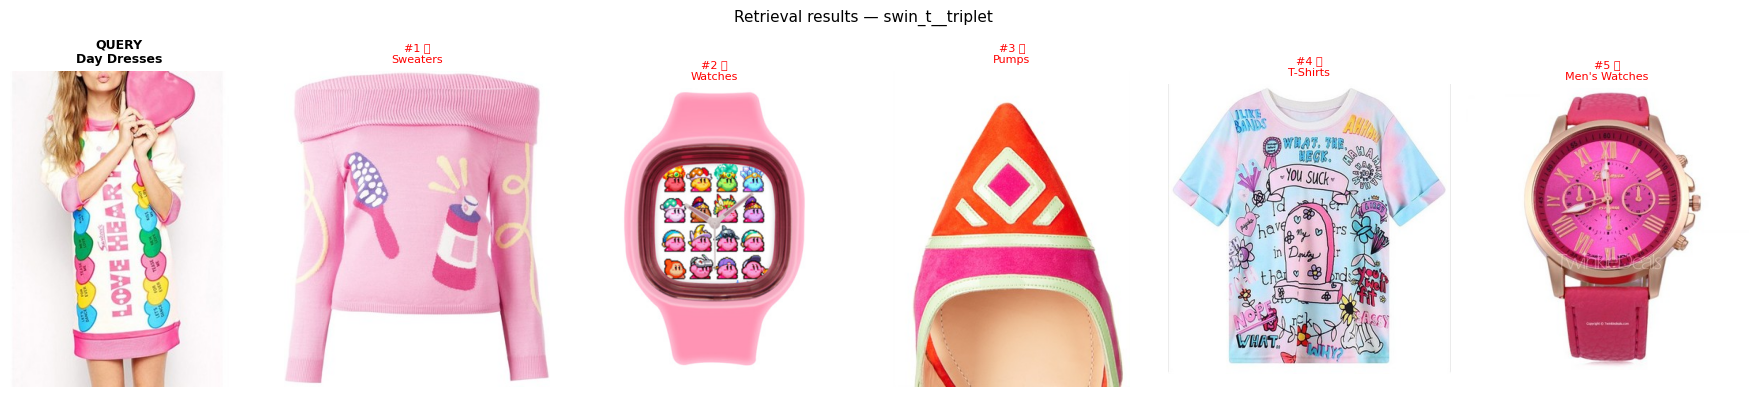

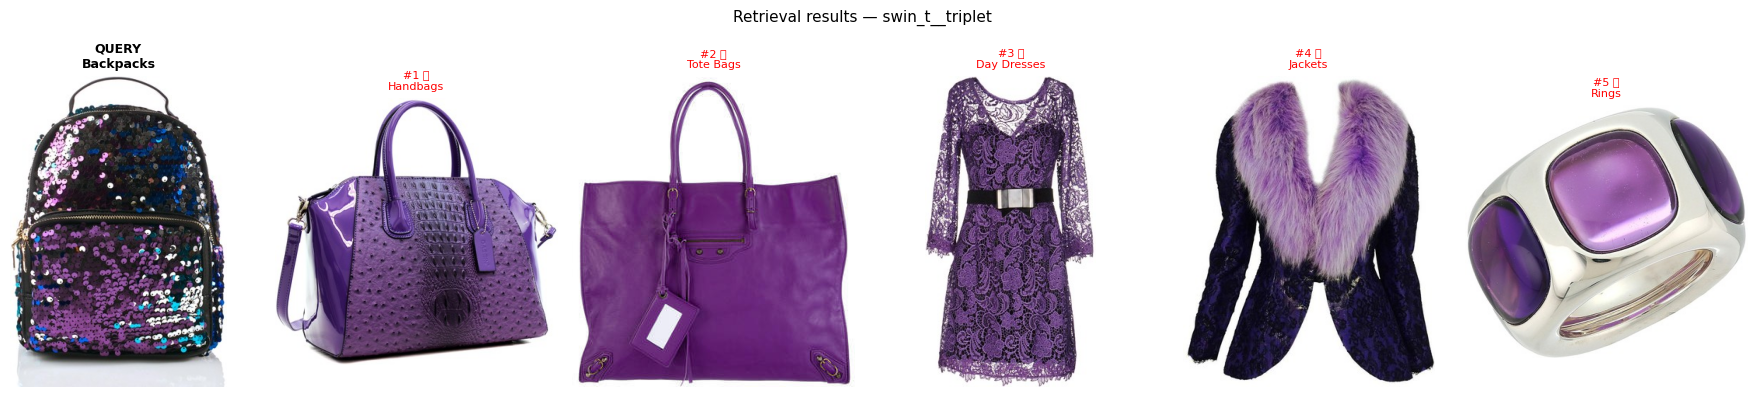

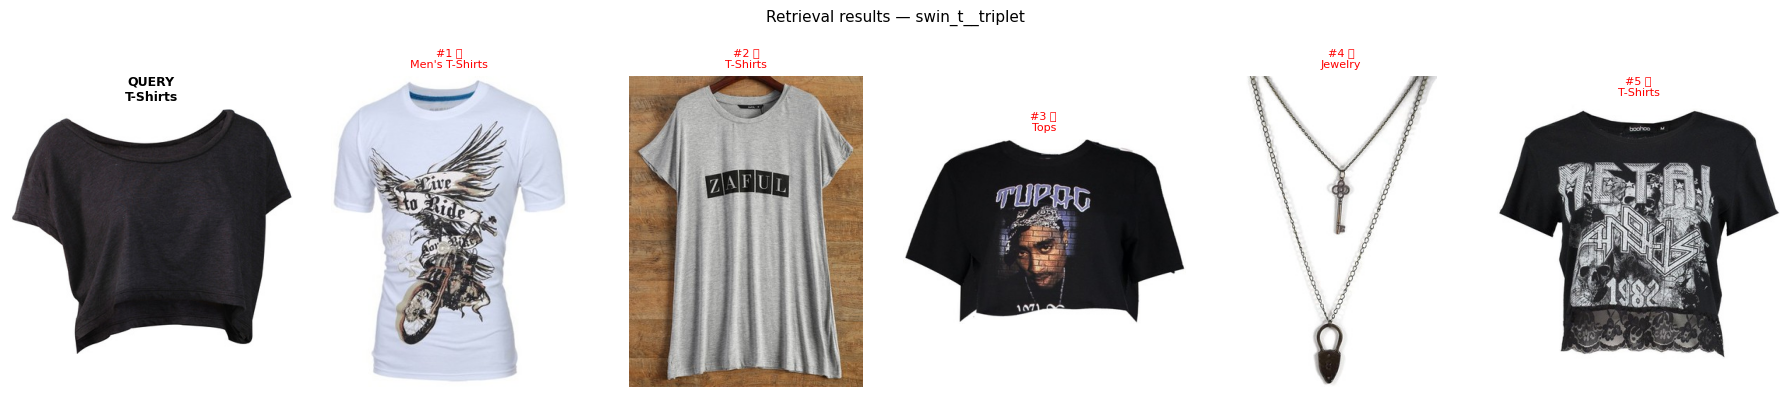

In [16]:
# Visualize retrieval results for the best model (swin_t__triplet)
BEST_RUN = max(all_metrics, key=lambda r: all_metrics[r]['auc'])
print(f'Best model by AUC: {BEST_RUN}')

# Re-extract embeddings for the best model
emb_db, db_outfit_ids, db_categories = extract_embeddings(BEST_RUN)

def visualize_retrieval(query_idx, k=5):
    """Show query item and its top-K most compatible retrieved items."""
    query_emb    = emb_db[query_idx]
    query_outfit = db_outfit_ids[query_idx]

    # Cosine similarity against full embedding DB
    sims = torch.matmul(emb_db, query_emb)
    sims[query_idx] = -1.0   # exclude the query item itself
    top_k = torch.topk(sims, k).indices.tolist()

    fig, axes = plt.subplots(1, k + 1, figsize=(3 * (k + 1), 4))

    # Query item
    axes[0].imshow(val_hf[query_idx]['image'])
    axes[0].set_title(f'QUERY\n{db_categories[query_idx][:15]}',
                      fontsize=9, fontweight='bold')
    axes[0].axis('off')

    # Retrieved items — green if from same outfit, red otherwise
    for rank, idx in enumerate(top_k, 1):
        is_match = db_outfit_ids[idx] == query_outfit
        axes[rank].imshow(val_hf[idx]['image'])
        axes[rank].set_title(
            f'#{rank} {"✅" if is_match else "❌"}\n{db_categories[idx][:15]}',
            fontsize=8, color='green' if is_match else 'red'
        )
        axes[rank].axis('off')

    plt.suptitle(f'Retrieval results — {BEST_RUN}', fontsize=11)
    plt.tight_layout()
    plt.show()

# Build outfit index and sample 3 query items
outfit_to_idx_eval = defaultdict(list)
for i, oid in enumerate(db_outfit_ids):
    outfit_to_idx_eval[oid].append(i)

query_pool = [idxs[0] for idxs in outfit_to_idx_eval.values() if len(idxs) >= 3]
for q in random.sample(query_pool, 3):
    visualize_retrieval(q, k=5)